# The code behind it: build the bootstrap & permutation test

*Part 2 · Lesson 20 · the code behind it  ·  data: Old Faithful · ToothGrowth (same as Lesson 20)*

*↩ A companion to [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb).*

**↩ Back:** [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](20-bootstrap-permutation~another-dataset.ipynb)

**In Lesson 20 the bootstrap and the permutation test felt almost magical** — resample, reshuffle, read
the answer off a histogram, no formula in sight. This companion **opens the hood**: you'll build both
engines *yourself*, in a handful of lines of NumPy, so "resample with replacement" stops being a phrase
and becomes code you could write from memory.

Same two datasets, same statistics, same final numbers — but the focus shifts from *what resampling
means* to **how you make a computer do it**. We go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load Old Faithful and ToothGrowth, the exact columns the core lesson used.
3. **Build it step by step** — the bootstrap CI and the permutation test from scratch, each checked against the textbook formula.
4. **The idiom** — `rng.choice` for the bootstrap, `rng.permutation` for the shuffle, and the vectorized one-liner.
5. **Refactor into functions** — wrap it all as reusable `bootstrap_ci(...)` and `permutation_test(...)`.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics, now demystified.

You don't need Lesson 20 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written two small engines from scratch:

- a **bootstrap** that resamples your data *with replacement* thousands of times to build a confidence
  interval (and a standard error) for **any** statistic — even a median, which has no SE formula;
- a **permutation test** that *shuffles group labels* thousands of times to build a null distribution
  and read off a p-value.

Nothing here needs new statistics — it's all in Lesson 20. What's new is the **Python underneath**: the
random-number generator, `rng.choice` and `rng.permutation`, and the trick of doing thousands of
resamples in one vectorized line. We'll check each engine against the classical formula it's supposed to
reproduce, and watch them come out **close** (resampling and a formula rarely match to the last decimal —
that's expected).

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **NumPy** | fast math on whole arrays | the resampling itself, percentiles, means |
| **`np.random.default_rng`** | a seedable random-number generator | drawing resamples and shuffles *reproducibly* |
| **scipy.stats** | classical tests | the t-interval and t-test we check against |
| **matplotlib** | plotting | the bootstrap and null distributions |

The one habit to absorb up front: **always create a seeded generator**, `rng = np.random.default_rng(0)`,
and draw every random thing from it. That makes the notebook reproducible — run it twice, get the same
numbers — which is non-negotiable for a result you want to trust.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

FAITHFUL_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv'
TOOTH_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/ToothGrowth.csv'

faithful = sl.load_csv('faithful.csv', url=FAITHFUL_URL)
tooth = sl.load_csv('ToothGrowth.csv', url=TOOTH_URL)
print(f'Old Faithful: shape {faithful.shape}   ToothGrowth: shape {tooth.shape}')
faithful.head()

Old Faithful: shape (272, 3)   ToothGrowth: shape (60, 4)


,rownames,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


## 2) The data in code

Before any resampling, a programmer *interrogates the objects*. Two datasets, exactly the columns the
core lesson used:

- **Old Faithful** — `faithful['eruptions']` is the eruption duration in minutes. We'll bootstrap its
  **median** (the bimodal data's honest "typical" value), and its **mean** to check against the formula.
- **ToothGrowth** — 60 guinea pigs given vitamin C as orange juice (`supp == 'OJ'`) or a synthetic
  supplement (`supp == 'VC'`); `len` is tooth length. We'll permute the **OJ vs VC** labels.

We pull the numbers out into plain NumPy arrays with `.to_numpy()` — `rng.choice` and `rng.permutation`
work most cleanly on arrays.

In [2]:
# Old Faithful: one column, as a NumPy array.
eruptions = faithful['eruptions'].to_numpy()
print('eruptions:', type(eruptions).__name__, 'of', len(eruptions), 'durations (minutes)')
print('first 5   :', np.round(eruptions[:5], 2))
print(f'sample mean   = {eruptions.mean():.4f} min')
print(f'sample median = {np.median(eruptions):.4f} min   <- the statistic with no SE formula')

# ToothGrowth: split into the two supplement groups with a boolean mask.
oj = tooth.loc[tooth['supp'] == 'OJ', 'len'].to_numpy()
vc = tooth.loc[tooth['supp'] == 'VC', 'len'].to_numpy()
print(f'\nOJ group: n = {len(oj)}, mean tooth length = {oj.mean():.3f}')
print(f'VC group: n = {len(vc)}, mean tooth length = {vc.mean():.3f}')
print(f'observed difference (OJ - VC) = {oj.mean() - vc.mean():.3f}')

eruptions: ndarray of 272 durations (minutes)
first 5   : [3.6  1.8  3.33 2.28 4.53]
sample mean   = 3.4878 min
sample median = 4.0000 min   <- the statistic with no SE formula

OJ group: n = 30, mean tooth length = 20.663
VC group: n = 30, mean tooth length = 16.963
observed difference (OJ - VC) = 3.700


## 3) Build it step by step

### 3a) One bootstrap resample — the whole trick in one line

The bootstrap treats *your sample as the population* and draws new samples **from it**, with replacement,
to the same size. That single line is `rng.choice(data, size=len(data), replace=True)`. "With
replacement" means a value can be drawn more than once — some original points appear twice, others not at
all. That reshuffling *is* the sample-to-sample wobble a standard error tries to capture.

In [3]:
rng = np.random.default_rng(0)          # one seeded generator, used for everything below
n = len(eruptions)

one_resample = rng.choice(eruptions, size=n, replace=True)   # same size n, WITH replacement
print(f'original : n = {n}, median = {np.median(eruptions):.3f} min')
print(f'resample : n = {len(one_resample)}, median = {np.median(one_resample):.3f} min')

# How many ORIGINAL positions never got drawn? (the famous ~37% = 1/e fact)
idx = rng.choice(np.arange(n), size=n, replace=True)
left_out = n - len(np.unique(idx))
print(f'\nthis resample left out {left_out} of {n} points ({left_out / n:.0%}) -- never drawn even once')
print('(on average a bootstrap sample misses about 1/e = 37% of the original points).')

original : n = 272, median = 4.000 min
resample : n = 272, median = 4.050 min

this resample left out 102 of 272 points (38%) -- never drawn even once
(on average a bootstrap sample misses about 1/e = 37% of the original points).


### 3b) The bootstrap distribution and a percentile CI

Now do that thousands of times, computing the **median** each time. The collection of medians is the
**bootstrap distribution** — our stand-in for the sampling distribution. A 95% confidence interval is
then just the **2.5th and 97.5th percentiles** of those medians (the *percentile method*), and the
**bootstrap standard error** is simply their standard deviation. No formula required.

In [4]:
reps = 10_000
boot_medians = np.empty(reps)
for i in range(reps):
    resample = rng.choice(eruptions, size=n, replace=True)
    boot_medians[i] = np.median(resample)

lo, hi = np.percentile(boot_medians, [2.5, 97.5])     # the percentile method
print(f'sample median             = {np.median(eruptions):.3f} min')
print(f'95% bootstrap CI (median) = ({lo:.3f}, {hi:.3f}) min')
print(f'bootstrap SE of median    = {boot_medians.std(ddof=1):.4f} min   <- no textbook formula exists for this!')

sample median             = 4.000 min


95% bootstrap CI (median) = (3.833, 4.108) min
bootstrap SE of median    = 0.0786 min   <- no textbook formula exists for this!


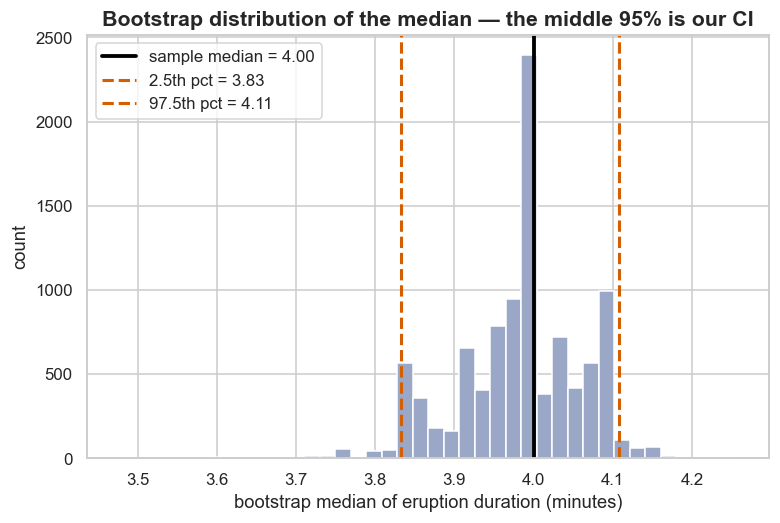

The "lumpy" spikes are real: the median of these data can only land on a few values, so
its bootstrap distribution is discrete. A smooth formula would have hidden that honesty.


In [5]:
fig, ax = plt.subplots()
ax.hist(boot_medians, bins=40, color='#9aa7c7', edgecolor='white')
ax.axvline(np.median(eruptions), color='black', lw=2.5, label=f'sample median = {np.median(eruptions):.2f}')
ax.axvline(lo, color='#D55E00', lw=2, ls='--', label=f'2.5th pct = {lo:.2f}')
ax.axvline(hi, color='#D55E00', lw=2, ls='--', label=f'97.5th pct = {hi:.2f}')
ax.set_xlabel('bootstrap median of eruption duration (minutes)'); ax.set_ylabel('count')
ax.set_title('Bootstrap distribution of the median — the middle 95% is our CI')
ax.legend(); plt.show()
print('The "lumpy" spikes are real: the median of these data can only land on a few values, so')
print('its bootstrap distribution is discrete. A smooth formula would have hidden that honesty.')

### 3c) Check it: bootstrap the *mean*, compare to the textbook formula

A new method earns trust by **agreeing with the old one where the old one works.** The classical
$t$-interval applies to the **mean**: $\bar{x} \pm 1.96\,s/\sqrt{n}$ (using $1.96$, the normal
multiplier, since $n = 272$ is large). Let's bootstrap the *mean* of the same eruptions and check the
two land in nearly the same place — **close, not identical**, because one is simulation and one is
algebra.

In [6]:
# (a) Bootstrap the MEAN, same machine, just swap np.median -> np.mean
boot_means = np.empty(reps)
for i in range(reps):
    boot_means[i] = rng.choice(eruptions, size=n, replace=True).mean()
b_lo, b_hi = np.percentile(boot_means, [2.5, 97.5])

# (b) Textbook normal-theory CI for the MEAN
xbar = eruptions.mean()
s    = eruptions.std(ddof=1)            # SAMPLE SD -> ddof=1
se   = s / np.sqrt(n)                   # the formula standard error of the mean
f_lo, f_hi = xbar - 1.96 * se, xbar + 1.96 * se

print(f'sample mean = {xbar:.4f} min\n')
print(f'bootstrap 95% CI (mean) = ({b_lo:.4f}, {b_hi:.4f})')
print(f'formula   95% CI (mean) = ({f_lo:.4f}, {f_hi:.4f})   <- close, not identical')
print()
print(f'bootstrap SE of mean    = {boot_means.std(ddof=1):.4f}')
print(f'formula  SE = s/sqrt(n) = {se:.4f}   <- the bootstrap rediscovered the formula')
print(f'\nthe two SEs agree to about {abs(boot_means.std(ddof=1) - se):.4f} -- close enough to trust the bootstrap.')

sample mean = 3.4878 min

bootstrap 95% CI (mean) = (3.3529, 3.6244)
formula   95% CI (mean) = (3.3521, 3.6234)   <- close, not identical

bootstrap SE of mean    = 0.0697
formula  SE = s/sqrt(n) = 0.0692   <- the bootstrap rediscovered the formula

the two SEs agree to about 0.0005 -- close enough to trust the bootstrap.


The bootstrap CI for the mean lands right on the textbook interval, and the bootstrap SE reproduces
$s/\sqrt{n}$. That's the validation: the bootstrap agrees with the formula where the formula applies, so
we trust it on the **median**, where no formula exists.

### 3d) The permutation test, from scratch

Now the second engine, on ToothGrowth. The observed gap is `oj.mean() - vc.mean()`. Under the null
hypothesis *"the OJ/VC label doesn't matter,"* the two groups are just one pooled set of 60 numbers cut
in two arbitrary halves. So we **pool, shuffle the labels, and recompute the gap** — thousands of times —
to build the distribution of the difference *when the null is true*. The **p-value** is the fraction of
shuffles whose gap is at least as extreme (in *either* direction) as the one we actually saw.

In [7]:
observed_diff = oj.mean() - vc.mean()
pooled = np.concatenate([oj, vc])       # one common pool of 60 lengths
N = len(pooled)
n_oj = len(oj)

null_diffs = np.empty(reps)
for i in range(reps):
    perm = rng.permutation(pooled)                       # randomly reassign all 60 labels
    null_diffs[i] = perm[:n_oj].mean() - perm[n_oj:].mean()

# two-sided p-value: how often does shuffling fake a gap this big, in either direction?
p_perm = np.mean(np.abs(null_diffs) >= np.abs(observed_diff))
print(f'observed difference (OJ - VC) = {observed_diff:.3f}')
print(f'permutation (shuffle) p-value = {p_perm:.4f}')
print(f'spread of the null shuffles   = {null_diffs.std(ddof=1):.3f}   (the "by-chance" wobble)')

observed difference (OJ - VC) = 3.700
permutation (shuffle) p-value = 0.0558
spread of the null shuffles   = 1.955   (the "by-chance" wobble)


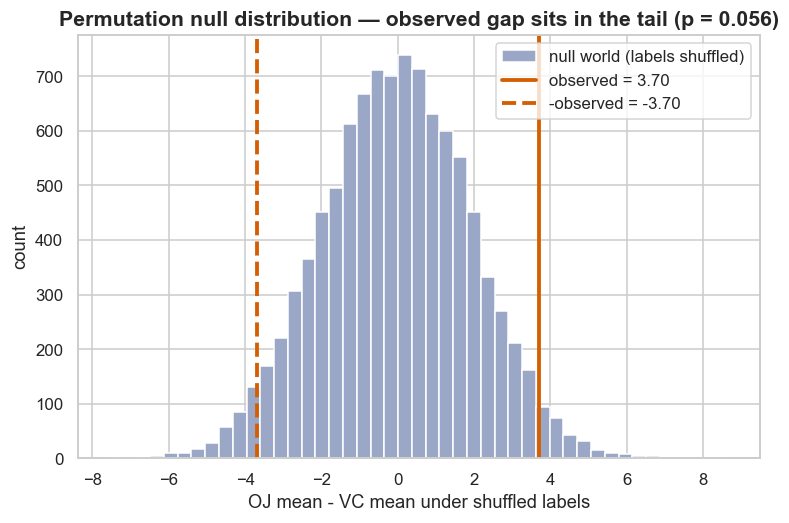

The p-value is the share of the grey histogram beyond the red lines: the chance that
shuffling alone fakes a gap as big as the one we observed.


In [8]:
fig, ax = plt.subplots()
ax.hist(null_diffs, bins=45, color='#9aa7c7', edgecolor='white', label='null world (labels shuffled)')
ax.axvline(observed_diff, color='#D55E00', lw=2.5, label=f'observed = {observed_diff:.2f}')
ax.axvline(-observed_diff, color='#D55E00', lw=2.5, ls='--', label=f'-observed = {-observed_diff:.2f}')
ax.set_xlabel('OJ mean - VC mean under shuffled labels'); ax.set_ylabel('count')
ax.set_title(f'Permutation null distribution — observed gap sits in the tail (p = {p_perm:.3f})')
ax.legend(); plt.show()
print('The p-value is the share of the grey histogram beyond the red lines: the chance that')
print('shuffling alone fakes a gap as big as the one we observed.')

### 3e) Check it: permutation p-value vs. the t-test

Same discipline. The classical tool here is the **two-sample t-test**. If our permutation p-value
roughly matches `scipy`'s, we reach the same conclusion with **fewer assumptions** — the permutation test
never assumed the data was normal.

In [9]:
t_result = stats.ttest_ind(oj, vc, equal_var=True)   # classic two-sample (Student) t-test
print(f'permutation test p-value = {p_perm:.4f}   (shuffling, no distribution assumed)')
print(f'scipy two-sample t-test  = {t_result.pvalue:.4f}   (assumes roughly normal data)')
print(f'\nthe two p-values agree to about {abs(p_perm - t_result.pvalue):.4f} -- they roughly AGREE.')
print('Both sit just ABOVE 0.05, so at the 5% threshold we do NOT reject H0: the OJ-vs-VC gap is')
print('suggestive but not quite "statistically significant" -- and the permutation test earned that')
print('answer without assuming normality.')

permutation test p-value = 0.0558   (shuffling, no distribution assumed)
scipy two-sample t-test  = 0.0604   (assumes roughly normal data)

the two p-values agree to about 0.0046 -- they roughly AGREE.
Both sit just ABOVE 0.05, so at the 5% threshold we do NOT reject H0: the OJ-vs-VC gap is
suggestive but not quite "statistically significant" -- and the permutation test earned that
answer without assuming normality.


## 4) The idiom — `rng.choice`, `rng.permutation`, and vectorizing the loop

### The two random moves

The whole lesson rests on two generator methods. Keep them straight:

- **Bootstrap** → `rng.choice(data, size=n, replace=True)` — draw `n` values *with* replacement (repeats
  allowed). This is sampling the *same* data over and over.
- **Permutation** → `rng.permutation(pooled)` — a random *reordering* of the pooled values, no repeats.
  This is reshuffling *labels*. (`rng.shuffle` does the same in place; `permutation` returns a fresh
  array, which is tidier.)

### Vectorizing: do all the resamples at once

The `for` loop above is clear, but NumPy can draw **every** bootstrap resample in a single call. Ask
`rng.choice` for a 2-D block of shape `(reps, n)` — one resample per row — then take the mean **along
each row** with `.mean(axis=1)`. No Python loop, and it's much faster.

In [10]:
# Vectorized bootstrap of the MEAN: a (reps x n) block, then collapse each row to its mean.
rng2 = np.random.default_rng(0)                                  # fresh seed -> reproducible
block = rng2.choice(eruptions, size=(reps, n), replace=True)     # reps resamples, all at once
boot_means_vec = block.mean(axis=1)                              # one mean per row

v_lo, v_hi = np.percentile(boot_means_vec, [2.5, 97.5])
print(f'vectorized bootstrap CI (mean) = ({v_lo:.4f}, {v_hi:.4f})')
print(f'looped bootstrap CI (mean)     = ({b_lo:.4f}, {b_hi:.4f})   <- same ballpark (different draws)')

import time
t0 = time.perf_counter()
_ = np.array([rng2.choice(eruptions, size=n, replace=True).mean() for _ in range(reps)])
t_loop = time.perf_counter() - t0
t0 = time.perf_counter()
_ = rng2.choice(eruptions, size=(reps, n), replace=True).mean(axis=1)
t_vec = time.perf_counter() - t0
print(f'\n{reps:,} resamples — loop: {t_loop*1000:6.1f} ms   vectorized: {t_vec*1000:6.1f} ms   '
      f'({t_loop/max(t_vec,1e-9):.0f}x faster)')

vectorized bootstrap CI (mean) = (3.3522, 3.6230)
looped bootstrap CI (mean)     = (3.3529, 3.6244)   <- same ballpark (different draws)



10,000 resamples — loop:   97.8 ms   vectorized:   15.4 ms   (6x faster)


## 5) Refactor into reusable functions

You've now written the bootstrap loop twice (median, then mean) and the permutation loop once. The
programmer's reflex is to **wrap repeated work in a function** with clear inputs and a `return`. Two
functions cover the whole lesson: `bootstrap_ci` takes *any* statistic function, and `permutation_test`
takes two groups. Pass in the seeded `rng` so the caller controls reproducibility.

In [11]:
def bootstrap_ci(data, statfn, reps=10_000, conf=0.95, rng=None):
    '''Percentile bootstrap CI for statfn(data). Returns (lo, hi).'''
    if rng is None:
        rng = np.random.default_rng(0)
    data = np.asarray(data)
    m = len(data)
    boot = np.array([statfn(rng.choice(data, size=m, replace=True)) for _ in range(reps)])
    alpha = (1 - conf) / 2
    return tuple(np.percentile(boot, [100 * alpha, 100 * (1 - alpha)]))


def permutation_test(a, b, reps=10_000, rng=None):
    '''Two-sided permutation p-value for (mean of a) - (mean of b) by shuffling labels.'''
    if rng is None:
        rng = np.random.default_rng(0)
    a, b = np.asarray(a), np.asarray(b)
    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    na = len(a)
    null = np.empty(reps)
    for i in range(reps):
        perm = rng.permutation(pooled)
        null[i] = perm[:na].mean() - perm[na:].mean()
    return float(np.mean(np.abs(null) >= np.abs(observed)))


rng = np.random.default_rng(0)
med_lo, med_hi = bootstrap_ci(eruptions, np.median, rng=rng)
print(f'bootstrap_ci(eruptions, median)  = ({med_lo:.3f}, {med_hi:.3f}) min')
print(f'permutation_test(oj, vc)         = {permutation_test(oj, vc, rng=rng):.4f}')
print('\nThe same two functions now work on any statistic and any two groups -- no copy-pasted loops.')

bootstrap_ci(eruptions, median)  = (3.833, 4.108) min


permutation_test(oj, vc)         = 0.0608

The same two functions now work on any statistic and any two groups -- no copy-pasted loops.


In [12]:
# Reuse on statistics that have NO clean SE formula at all — the whole point of resampling:
rng = np.random.default_rng(0)
for name, fn in [('median', np.median), ('mean', np.mean),
                 ('std',  lambda x: x.std(ddof=1)),
                 ('90th pct', lambda x: np.percentile(x, 90))]:
    lo_, hi_ = bootstrap_ci(eruptions, fn, rng=rng)
    print(f'95% CI for the {name:9} of eruption duration: ({lo_:.3f}, {hi_:.3f})')

95% CI for the median    of eruption duration: (3.833, 4.108)
95% CI for the mean      of eruption duration: (3.353, 3.624)


95% CI for the std       of eruption duration: (1.087, 1.184)


95% CI for the 90th pct  of eruption duration: (4.615, 4.800)


That last cell is the punchline of the whole topic: the **same five lines** give you a confidence
interval for the median, the SD, or the 90th percentile — statistics the classical toolkit hands you no
formula for. Resampling doesn't care; it just redoes the experiment.

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the
answer before you run it.

1. **Bootstrap a different statistic.** Call `bootstrap_ci(eruptions, np.mean, rng=np.random.default_rng(0))`
   and confirm it lands close to the formula CI `(f_lo, f_hi)` from Section 3c. They won't match to the
   decimal — say *why* (one is simulation, one is algebra).

2. **A bigger effect, same test.** ToothGrowth also has a `dose` column. Pull the high and low doses and
   run the permutation test:

       hi = tooth.loc[tooth['dose'] == 2.0, 'len'].to_numpy()
       lo = tooth.loc[tooth['dose'] == 0.5, 'len'].to_numpy()
       print(permutation_test(hi, lo, rng=np.random.default_rng(0)))

   This gap should be *much* bigger than OJ-vs-VC. Is the p-value now tiny? What does that mean?

3. **More resamples, steadier answer.** Run `bootstrap_ci(eruptions, np.median, reps=R, rng=np.random.default_rng(0))`
   for `R = 500`, `5_000`, `50_000`. Watch the endpoints settle down. (More resamples cut *Monte-Carlo*
   noise — not the limits of your original sample.)

4. **Confirm the bootstrap SE matches the formula.** For the *mean*, build the bootstrap distribution and
   compare `boot.std(ddof=1)` to `eruptions.std(ddof=1) / np.sqrt(len(eruptions))`. How close are they?

## What you learned

**Coding**
- **Always seed your randomness:** `rng = np.random.default_rng(0)`, and draw everything from `rng`, so
  the notebook gives the same numbers every run. Never use bare, unseeded `np.random` in a result you
  want to trust.
- **The bootstrap is one line:** `rng.choice(data, size=len(data), replace=True)` — draw with
  replacement, same size, repeats allowed.
- **The permutation is one line:** `rng.permutation(pooled)` — a random reordering with no repeats, used
  to reshuffle *labels*.
- **Vectorize the loop:** `rng.choice(data, size=(reps, n))` then `.mean(axis=1)` does every bootstrap
  resample at once — same answer, far faster, no Python loop.
- **Refactor repeated work into functions** (`bootstrap_ci(data, statfn, ...)`,
  `permutation_test(a, b, ...)`) that take the statistic / groups and the `rng` as arguments, then reuse
  them everywhere.

**Statistics (now demystified)**
- A **bootstrap percentile CI** is just `np.percentile(boot_stats, [2.5, 97.5])`, and the **bootstrap
  SE** is `boot_stats.std(ddof=1)` — you reproduced the textbook mean CI and its $s/\sqrt{n}$ standard
  error to a *close* match (simulation vs. formula never coincide exactly).
- A **permutation p-value** is `np.mean(np.abs(null) >= np.abs(observed))` after shuffling labels — and
  it roughly **agreed** with `scipy.stats.ttest_ind` while assuming no normality.
- Resampling shines exactly where formulas run out: a **median, an SD, a percentile** (no SE formula) and
  **tiny or skewed samples**.

**Back to the core lesson** ([Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb))
for the *meaning* of these intervals and p-values, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 20: The bootstrap & permutation tests](20-bootstrap-permutation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](20-bootstrap-permutation~another-dataset.ipynb)